<a href="https://colab.research.google.com/github/madaam99/EnergyGermany/blob/main/Modelling/Modelling_SMARD_EnergyProduction_Germany_Monthly.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
!pip install utilsforecast statsforecast mlforecast neuralforecast

In [47]:
from google.colab import files

In [48]:
upload = files.upload()

Saving processedErzeugungMonthly to processedErzeugungMonthly (1)


In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import *

from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, SeasonalNaive

from mlforecast import MLForecast
from mlforecast.target_transforms import LocalStandardScaler
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from neuralforecast import NeuralForecast
from neuralforecast.models import NHITS, TFT

import warnings
warnings.filterwarnings('ignore')

In [50]:
erzeugung = pd.read_csv("processedErzeugungMonthly")

erzeugung.tail()

,Datum von,Datum bis,Gesamterzeugung [MWh],Biomasse [MWh],Wasserkraft [MWh],Wind Offshore [MWh],Wind Onshore [MWh],Photovoltaik [MWh],Sonstige Erneuerbare [MWh],Kernenergie [MWh],Braunkohle [MWh],Steinkohle [MWh],Erdgas [MWh],Pumpspeicher [MWh],Sonstige Konventionelle [MWh]
54,2025-07-01,2025-08-01,33616454.59,2882519.84,1405119.49,1561247.83,6167800.71,9056373.02,66518.95,0.0,5754061.25,1909475.25,2927114.00,808930.25,1077294.00
55,2025-08-01,2025-09-01,31975152.15,2852499.35,1463011.45,1699077.95,5459159.51,9672278.48,73973.16,0.0,4518747.75,1301445.00,3015974.75,843045.25,1075939.50
56,2025-09-01,2025-10-01,34504645.87,2794210.42,1208876.63,2410541.28,9721142.41,6435895.39,72157.99,0.0,4925688.75,1397569.00,3790773.75,733651.25,1014139.00
57,2025-10-01,2025-11-01,39873287.81,3012369.21,1101271.62,2899280.50,13715347.63,3838084.50,65807.22,0.0,5648721.13,2166156.53,5275413.52,756737.01,1394098.94
58,2025-11-01,2025-12-01,38483562.69,3116940.82,1000809.27,2712668.41,9865268.03,2372958.50,67962.49,0.0,6595504.11,3165924.61,7504834.06,730029.59,1350662.80


In [51]:
erzeugung['Datum von'] = pd.to_datetime(erzeugung['Datum von'])
erzeugung['Datum bis'] = pd.to_datetime(erzeugung['Datum bis'])

##Modelling with Production as Focus

Melting DFs and renaming to fit statsforecast, mlforecast, and neuralforecast better

In [52]:
erzeugung_melted = erzeugung.drop(columns="Datum bis").melt(id_vars=['Datum von'], var_name='unique_id', value_name='y')

erzeugung_melted.rename(columns={'Datum von': 'ds'}, inplace=True)

erzeugung_melted.head()

,ds,unique_id,y
0,2021-01-01,Gesamterzeugung [MWh],47170005.5
1,2021-02-01,Gesamterzeugung [MWh],41770396.5
2,2021-03-01,Gesamterzeugung [MWh],45452515.0
3,2021-04-01,Gesamterzeugung [MWh],42260696.0
4,2021-05-01,Gesamterzeugung [MWh],39597867.0


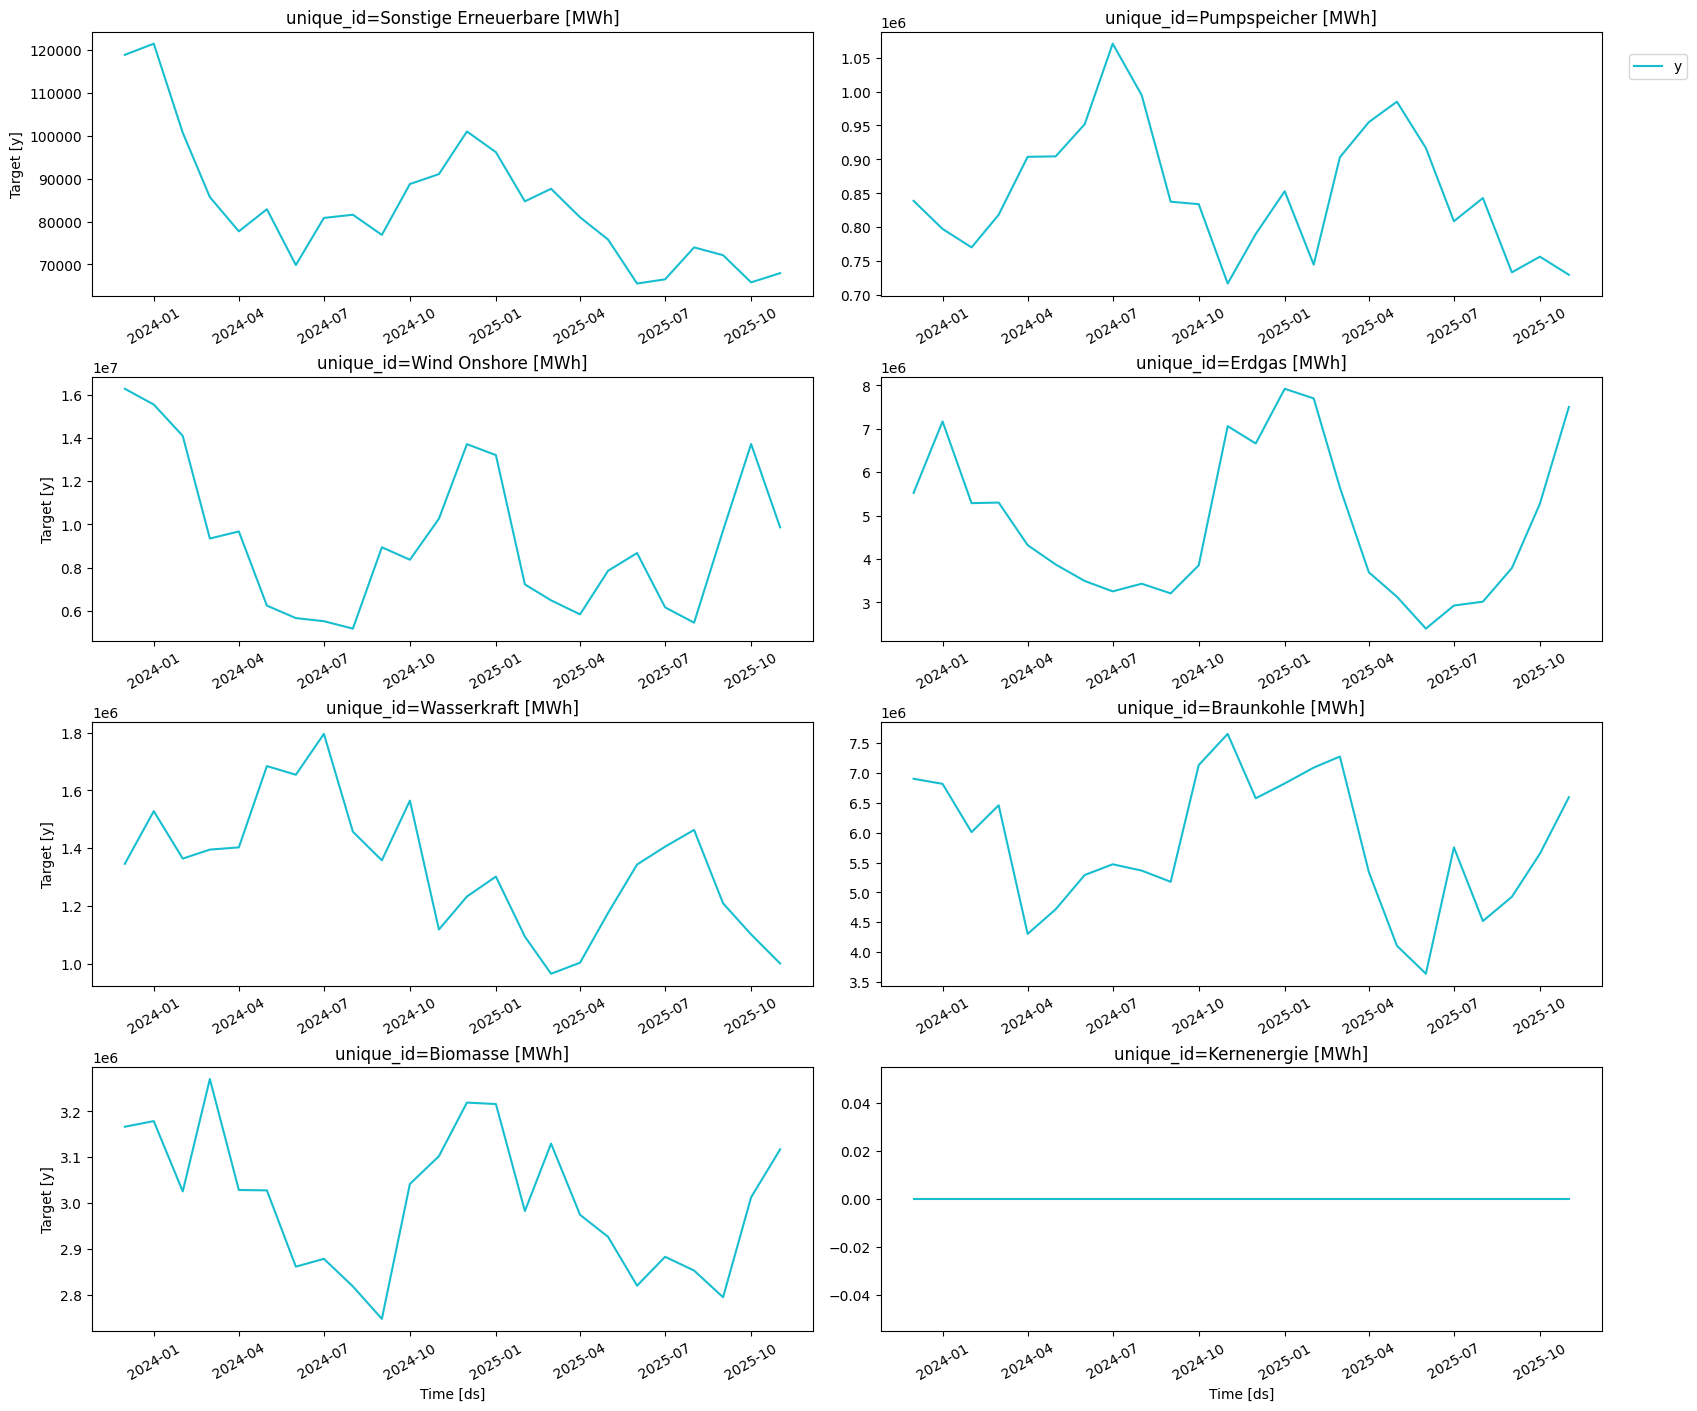

In [53]:
plot_series(df=erzeugung_melted, max_insample_length=24)

In [54]:
testErzeugungStat = erzeugung_melted.groupby('unique_id').tail(3)
trainErzeugungStat = erzeugung_melted.drop(testErzeugungStat.index)

###Statsforecast

In [55]:
models = [
    AutoARIMA(alias="ARIMA"),
    AutoARIMA(season_length=12, alias="SARIMA"),
    SeasonalNaive(season_length=12)
]

sf = StatsForecast(models=models, freq='MS')
sf.fit(trainErzeugungStat)
predStatErz = sf.predict(3)

predStatErz.head()

,unique_id,ds,ARIMA,SARIMA,SeasonalNaive
0,Biomasse [MWh],2025-09-01,2.867677e+06,2.735789e+06,2747048.00
1,Biomasse [MWh],2025-10-01,2.860004e+06,2.978532e+06,3041499.25
2,Biomasse [MWh],2025-11-01,2.863883e+06,3.025379e+06,3102041.50
3,Braunkohle [MWh],2025-09-01,4.518748e+06,4.710650e+06,5177279.75
4,Braunkohle [MWh],2025-10-01,4.518748e+06,5.551230e+06,7134012.25


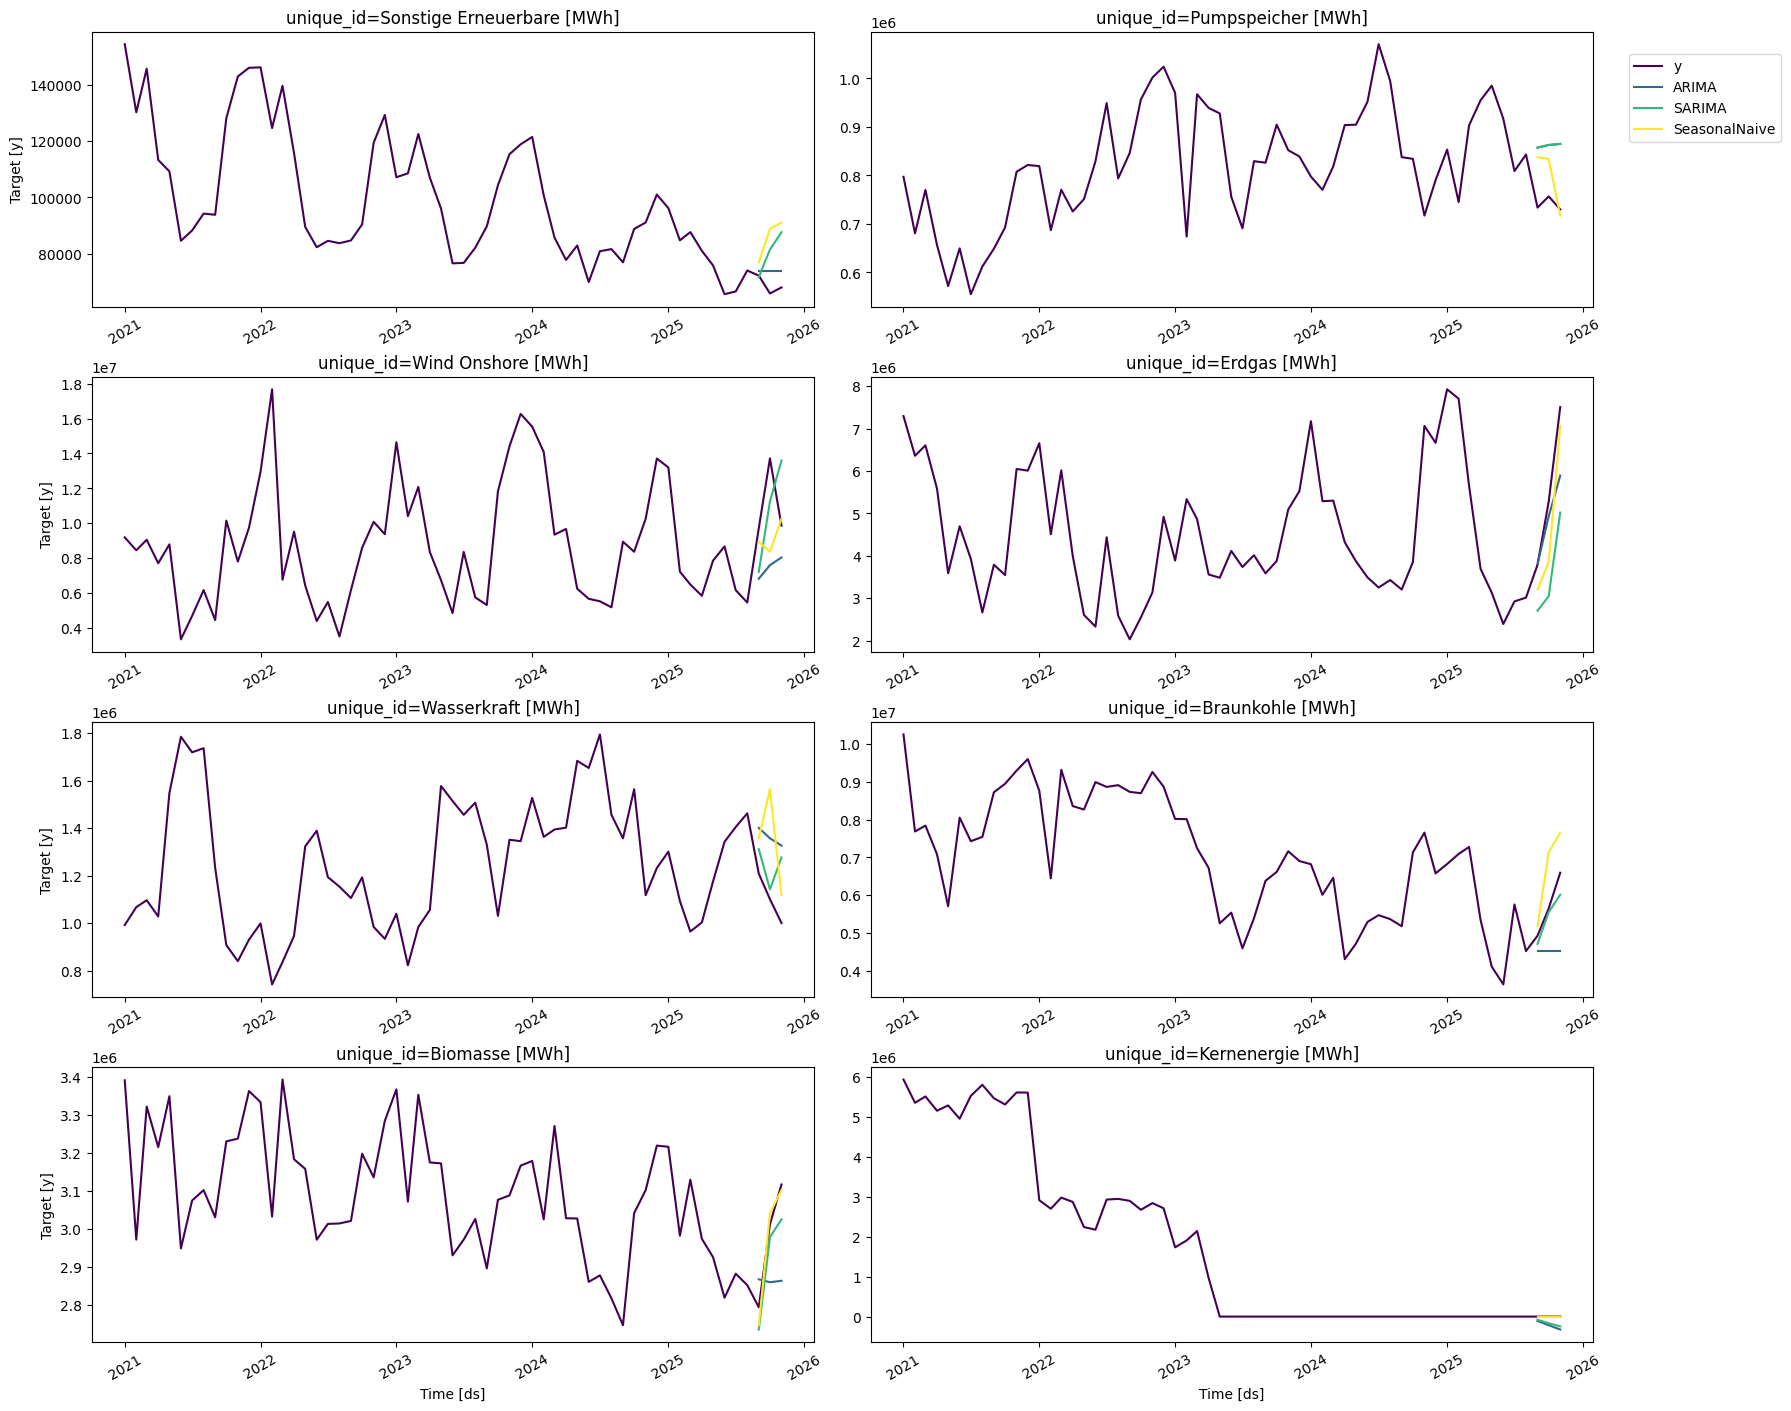

In [56]:
plot_series(df=erzeugung_melted, forecasts_df=predStatErz, palette="viridis")

In [57]:
eval_df = pd.merge(testErzeugungStat, predStatErz, "left", ["ds", "unique_id"])
evaluation = evaluate(eval_df, metrics=[mae])
evaluation.head()

,unique_id,metric,ARIMA,SARIMA,SeasonalNaive
0,Biomasse [MWh],mae,1.596300e+05,6.127373e+04,3.039726e+04
1,Braunkohle [MWh],mae,1.204557e+06,2.988497e+05,9.331188e+05
2,Erdgas [MWh],mae,6.583694e+05,1.931216e+06,8.162292e+05
3,Gesamterzeugung [MWh],mae,5.645347e+06,3.163327e+06,2.009045e+06
4,Kernenergie [MWh],mae,2.154683e+05,1.630782e+05,0.000000e+00


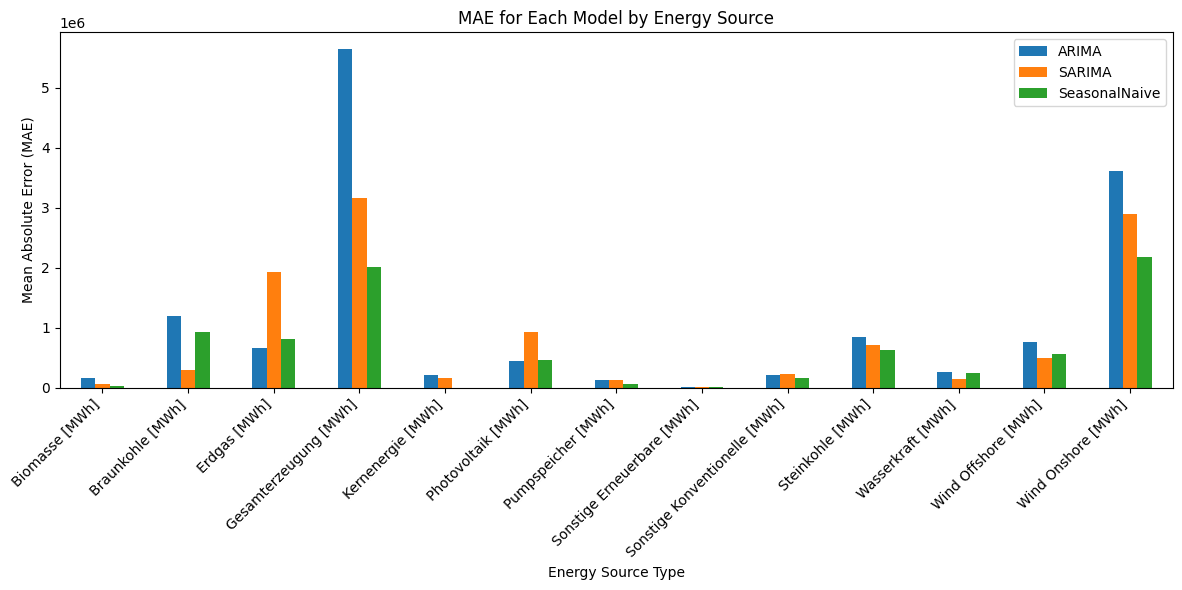

In [58]:
evaluation_for_plot = evaluation.set_index('unique_id')
evaluation_for_plot = evaluation_for_plot.drop(columns='metric')

evaluation_for_plot.plot(kind="bar", figsize=(12, 6))
plt.ylabel("Mean Absolute Error (MAE)")
plt.xlabel("Energy Source Type")
plt.title("MAE for Each Model by Energy Source")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Cross-validation

In [59]:
models = [
    AutoARIMA(alias="ARIMA"),
    AutoARIMA(season_length=12, alias="SARIMA"),
    SeasonalNaive(season_length=12)
]

sf = StatsForecast(models=models, freq='MS')
cv = sf.cross_validation(
    df=trainErzeugungStat,
    h=3,
    step_size=3,
    n_windows=4,
    refit=True,
)

cv.head()

,unique_id,ds,cutoff,y,ARIMA,SARIMA,SeasonalNaive
0,Biomasse [MWh],2024-09-01,2024-08-01,2747048.00,2.851359e+06,2.789965e+06,2896349.50
1,Biomasse [MWh],2024-10-01,2024-08-01,3041499.25,2.832734e+06,2.968999e+06,3076700.75
2,Biomasse [MWh],2024-11-01,2024-08-01,3102041.50,2.843098e+06,2.954968e+06,3088185.75
3,Biomasse [MWh],2024-12-01,2024-11-01,3219102.00,3.070527e+06,3.081032e+06,3166389.25
4,Biomasse [MWh],2025-01-01,2024-11-01,3215965.00,3.086931e+06,3.093329e+06,3178686.00


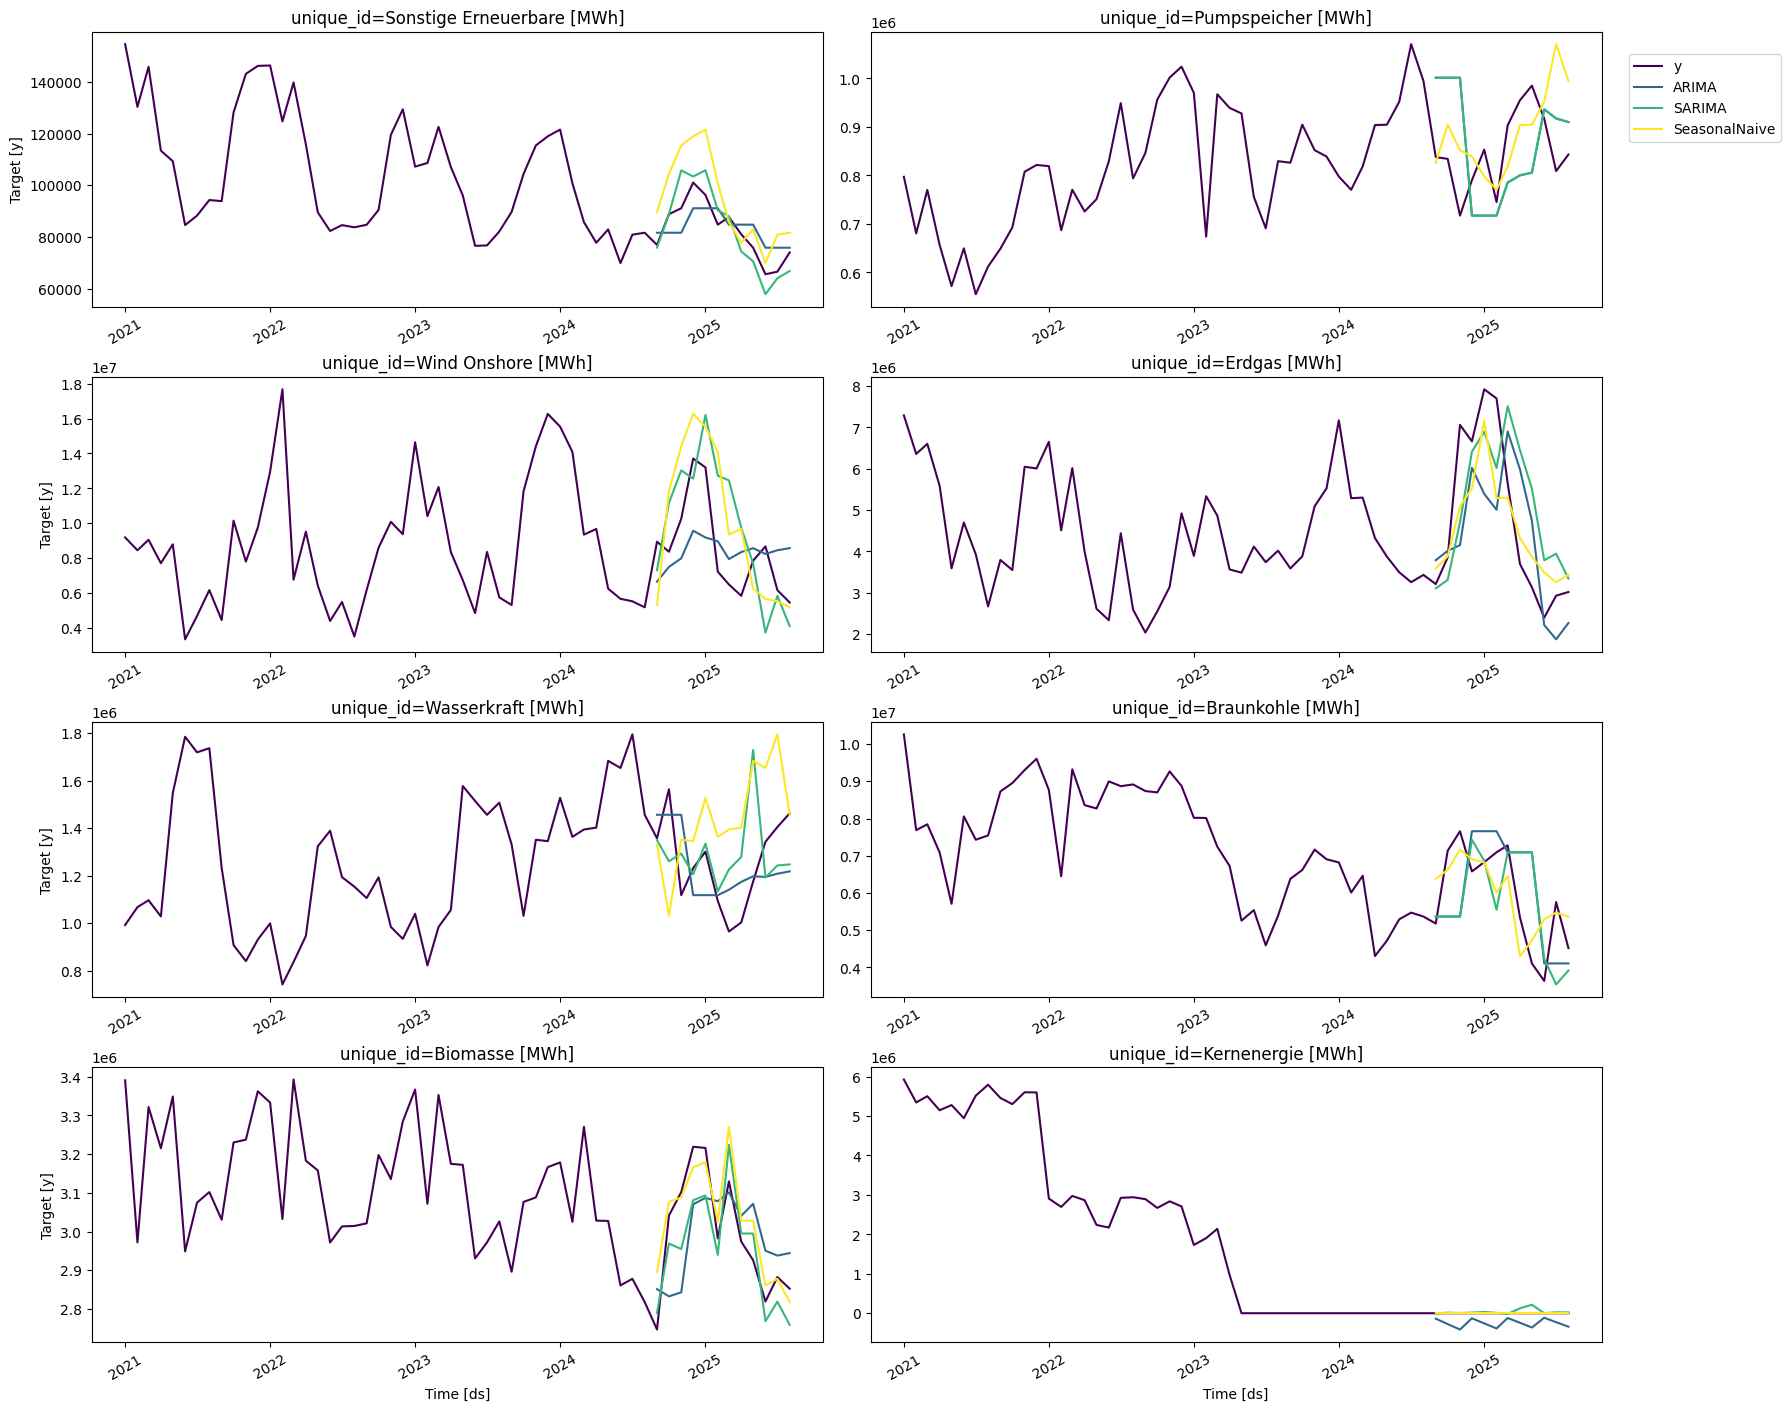

In [60]:
plot_series(df=trainErzeugungStat, forecasts_df=cv.drop(columns=["y", "cutoff"]), palette="viridis")

In [61]:
cv_eval = evaluate(cv.drop(columns="cutoff"), metrics=[mae])

cv_eval = cv_eval.drop(columns=["unique_id"]).groupby("metric").mean().reset_index()
cv_eval

,metric,ARIMA,SARIMA,SeasonalNaive
0,mae,820159.320196,702315.415744,680541.780641


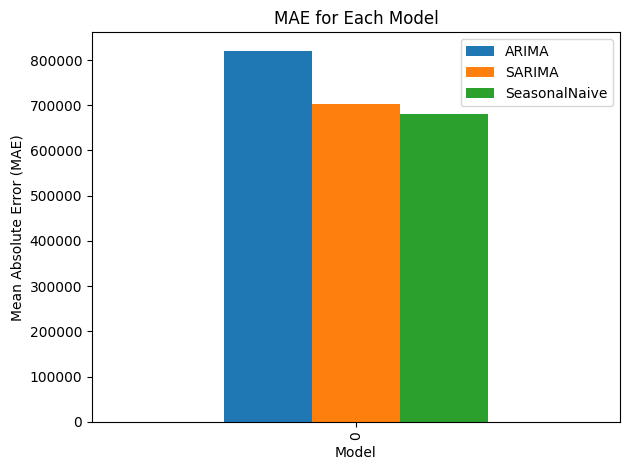

In [62]:
cv_eval.plot(kind="bar")
plt.ylabel("Mean Absolute Error (MAE)")
plt.xlabel("Model")
plt.title("MAE for Each Model")
plt.tight_layout()
plt.show()

###MLForecast

Creating train and test set in desired format

In [63]:
testErzeugung = erzeugung.tail(3)
trainErzeugung = erzeugung.drop(testErzeugung.index)

In [64]:
trainErzeugung = trainErzeugung.drop(columns="Datum bis").melt(id_vars=['Datum von'], var_name='unique_id', value_name='y')
testErzeugung = testErzeugung.drop(columns="Datum bis").melt(id_vars=['Datum von'], var_name='unique_id', value_name='y')

trainErzeugung.rename(columns={'Datum von': 'ds'}, inplace=True)
testErzeugung.rename(columns={'Datum von': 'ds'}, inplace=True)

display(trainErzeugung.tail())
display(testErzeugung.tail())

,ds,unique_id,y
723,2025-04-01,Sonstige Konventionelle [MWh],1169981.00
724,2025-05-01,Sonstige Konventionelle [MWh],1182706.25
725,2025-06-01,Sonstige Konventionelle [MWh],1064827.75
726,2025-07-01,Sonstige Konventionelle [MWh],1077294.00
727,2025-08-01,Sonstige Konventionelle [MWh],1075939.50


,ds,unique_id,y
34,2025-10-01,Pumpspeicher [MWh],756737.01
35,2025-11-01,Pumpspeicher [MWh],730029.59
36,2025-09-01,Sonstige Konventionelle [MWh],1014139.00
37,2025-10-01,Sonstige Konventionelle [MWh],1394098.94
38,2025-11-01,Sonstige Konventionelle [MWh],1350662.80


Modelling with MLForecast

In [65]:
models = [
    LinearRegression(),
    XGBRegressor(),
    LGBMRegressor()
]

mlf = MLForecast(models=models, freq='MS', lags=list(range(1, 12)), target_transforms=[LocalStandardScaler()])

mlf.fit(trainErzeugung)
predMlErz = mlf.predict(3)

predMlErz.head()

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000380 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2151
[LightGBM] [Info] Number of data points in the train set: 585, number of used features: 11
[LightGBM] [Info] Start training from score -0.042351
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

,unique_id,ds,LinearRegression,XGBRegressor,LGBMRegressor
0,Biomasse [MWh],2025-09-01,2.959830e+06,2.904058e+06,2.835910e+06
1,Biomasse [MWh],2025-10-01,3.011095e+06,2.988186e+06,2.980338e+06
2,Biomasse [MWh],2025-11-01,3.071862e+06,3.079103e+06,3.126456e+06
3,Braunkohle [MWh],2025-09-01,5.531696e+06,5.501329e+06,5.503749e+06
4,Braunkohle [MWh],2025-10-01,6.079332e+06,6.362785e+06,6.182884e+06


In [66]:
eval_df = pd.merge(testErzeugung, predMlErz, "left", ["ds", "unique_id"])
evaluation = evaluate(eval_df, metrics=[mae])
evaluation.head()

,unique_id,metric,LinearRegression,XGBRegressor,LGBMRegressor
0,Biomasse [MWh],mae,7.065768e+04,5.728935e+04,2.774841e+04
1,Braunkohle [MWh],mae,4.147647e+05,4.719210e+05,4.275010e+05
2,Erdgas [MWh],mae,8.146580e+05,1.484158e+06,1.633504e+06
3,Gesamterzeugung [MWh],mae,1.267151e+06,4.175947e+06,4.116710e+06
4,Kernenergie [MWh],mae,4.107098e+05,6.928773e+02,5.481976e+03


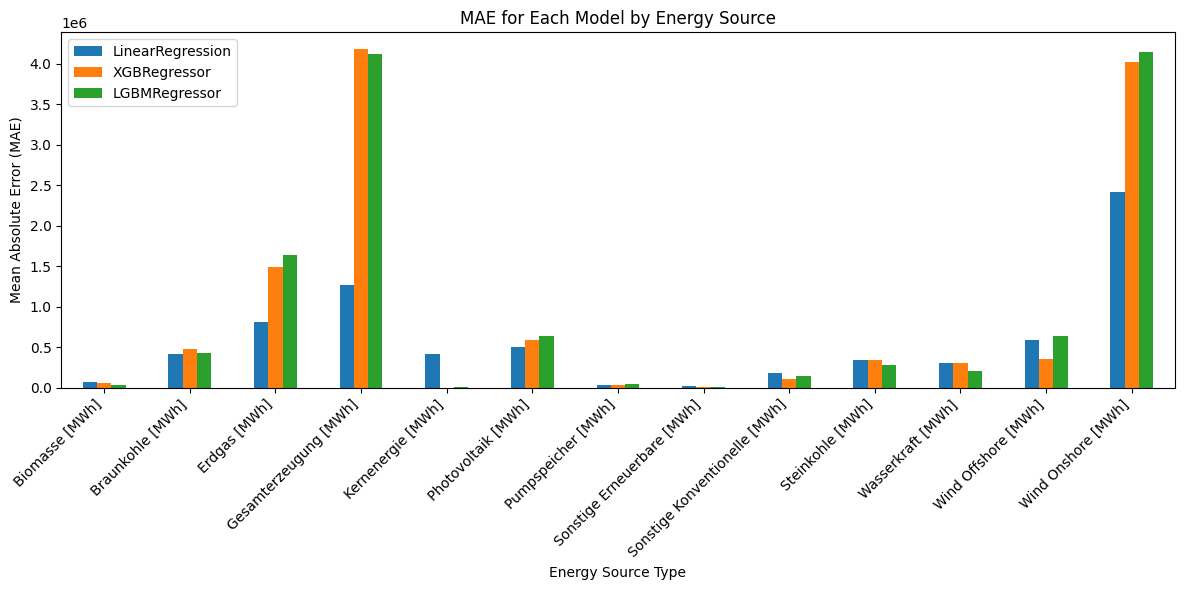

In [67]:
evaluation_to_plot = evaluation.drop(columns="metric").set_index("unique_id")

evaluation_to_plot.plot(kind="bar", figsize=(12, 6))
plt.ylabel("Mean Absolute Error (MAE)")
plt.xlabel("Energy Source Type")
plt.title("MAE for Each Model by Energy Source")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

ML Cross-Validation

In [68]:
models = [
    LinearRegression(),
    XGBRegressor(),
    LGBMRegressor()
]

mlf = MLForecast(models=models, freq="MS", lags=list(range(1, 13)), target_transforms=[LocalStandardScaler()])

cv_ml = mlf.cross_validation(df=trainErzeugung, n_windows=4, h=3)

cv_ml

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000049 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1668
[LightGBM] [Info] Number of data points in the train set: 416, number of used features: 12
[LightGBM] [Info] Start training from score -0.060975
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

,unique_id,ds,cutoff,y,LinearRegression,XGBRegressor,LGBMRegressor
0,Biomasse [MWh],2024-09-01,2024-08-01,2747048.00,2.912400e+06,2.915326e+06,2.897300e+06
1,Biomasse [MWh],2024-10-01,2024-08-01,3041499.25,2.944350e+06,2.950868e+06,2.952261e+06
2,Biomasse [MWh],2024-11-01,2024-08-01,3102041.50,3.018229e+06,3.018775e+06,2.987339e+06
3,Braunkohle [MWh],2024-09-01,2024-08-01,5177279.75,6.150529e+06,4.958405e+06,5.304178e+06
4,Braunkohle [MWh],2024-10-01,2024-08-01,7134012.25,6.526551e+06,5.961409e+06,5.703480e+06
...,...,...,...,...,...,...,...
151,Wind Offshore [MWh],2025-07-01,2025-05-01,1561247.83,1.626512e+06,1.222705e+06,1.118241e+06
152,Wind Offshore [MWh],2025-08-01,2025-05-01,1699077.95,1.686368e+06,1.331052e+06,1.345187e+06
153,Wind Onshore [MWh],2025-06-01,2025-05-01,8676526.75,6.308742e+06,5.266711e+06,5.595607e+06
154,Wind Onshore [MWh],2025-07-01,2025-05-01,6167800.71,6.252707e+06,5.294896e+06,4.562909e+06


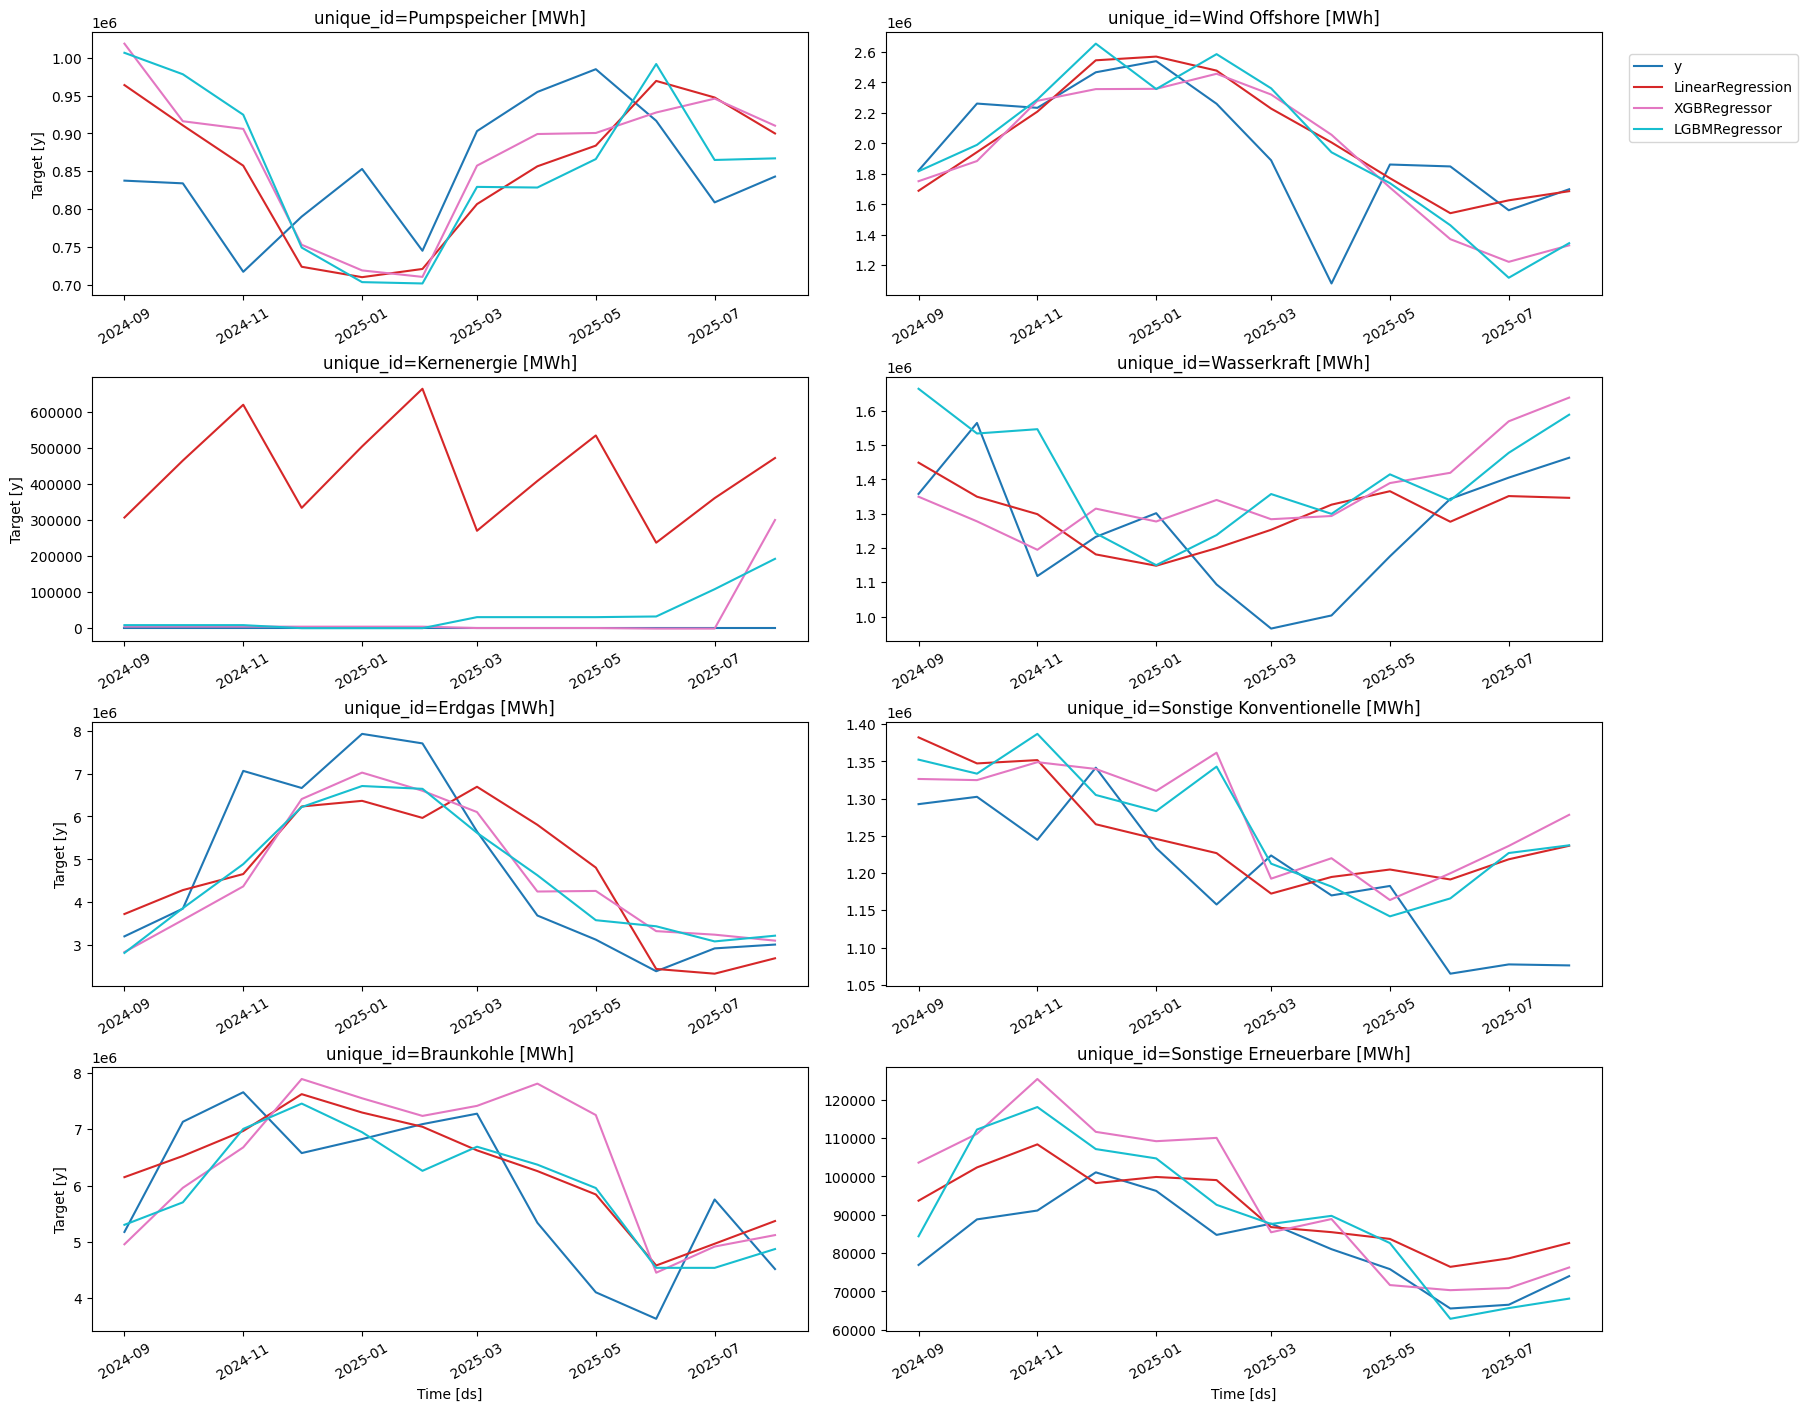

In [69]:
plot_series(forecasts_df=cv_ml.drop(columns='cutoff'))

In [70]:
mlf_cv_eval = evaluate(cv_ml.drop(columns="cutoff"), metrics=[mae])

mlf_cv_eval = mlf_cv_eval.drop(columns=["unique_id"]).groupby("metric").mean().reset_index()
mlf_cv_eval

,metric,LinearRegression,XGBRegressor,LGBMRegressor
0,mae,634660.964019,657940.172949,690088.923204


<Axes: >

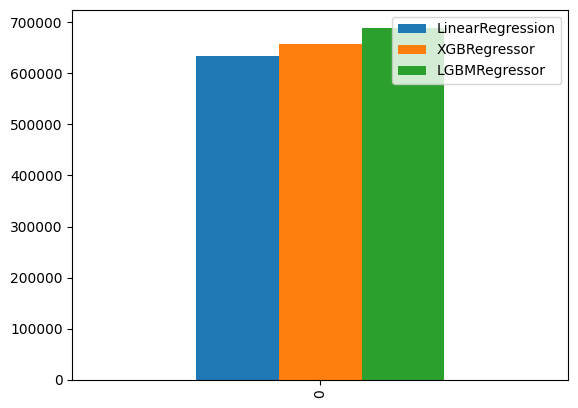

In [71]:
mlf_cv_eval.plot(kind="bar")

In [72]:
mlf_cv_eval = evaluate(cv_ml.drop(columns="cutoff"), metrics=[mae])
mlf_to_plot = mlf_cv_eval.drop(columns="metric").set_index("unique_id")
mlf_to_plot

,LinearRegression,XGBRegressor,LGBMRegressor
unique_id,,,
Biomasse [MWh],7.473400e+04,9.631858e+04,1.113551e+05
Braunkohle [MWh],8.102916e+05,1.047409e+06,8.319258e+05
Erdgas [MWh],1.073161e+06,7.562504e+05,6.770245e+05
Gesamterzeugung [MWh],1.633853e+06,1.708066e+06,1.922992e+06
Kernenergie [MWh],4.321236e+05,2.755069e+04,3.768864e+04
Photovoltaik [MWh],1.560785e+06,1.744954e+06,1.760802e+06
Pumpspeicher [MWh],9.339296e+04,8.823935e+04,1.023824e+05
Sonstige Erneuerbare [MWh],9.426221e+03,1.314639e+04,8.772197e+03
Sonstige Konventionelle [MWh],7.714511e+04,8.662903e+04,8.173142e+04


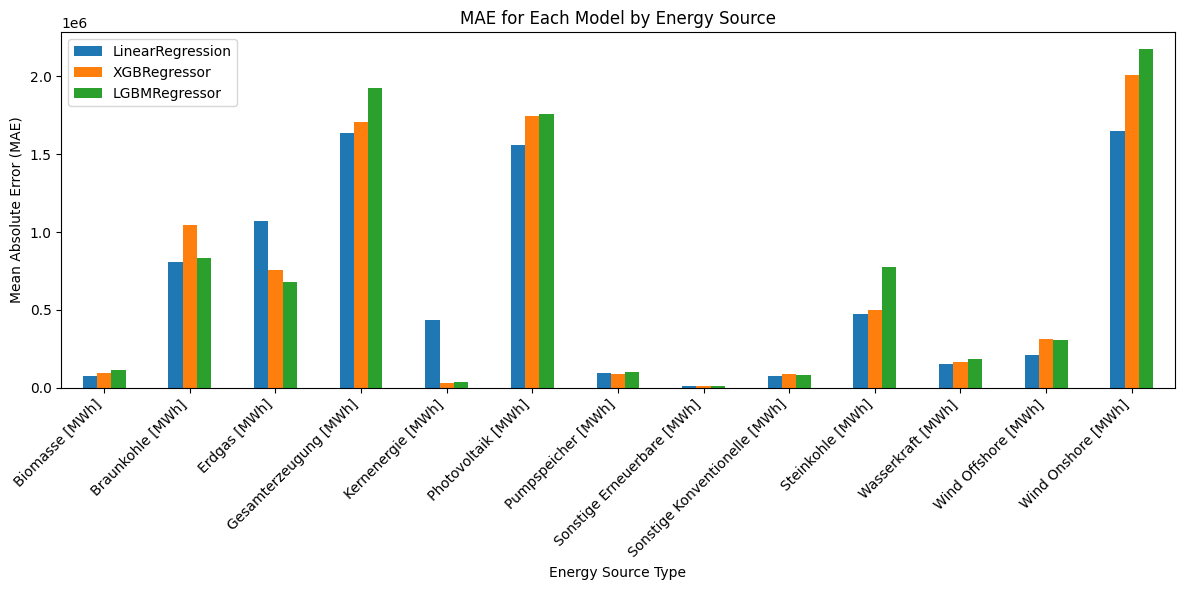

In [73]:
mlf_to_plot.plot(kind="bar", figsize=(12, 6))
plt.ylabel("Mean Absolute Error (MAE)")
plt.xlabel("Energy Source Type")
plt.title("MAE for Each Model by Energy Source")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

###NeuralForecast

In [74]:
models = [
    NHITS(h=3, input_size=12, n_pool_kernel_size=[4,2,1], n_freq_downsample=[12,4,1], scaler_type='robust', max_steps=1000, enable_progress_bar=False),
    TFT(h=3, input_size=12, hidden_size=128, scaler_type='robust', learning_rate=5e-4, max_steps=500, enable_progress_bar=False)
]

nf = NeuralForecast(models=models, freq='MS', local_scaler_type="standard")

nf.fit(trainErzeugung)

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ blocks       │ ModuleList    │  2.4 M │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 2.4 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.4 M                                                                                                
Total estimated model params size (MB): 9                                                                          
Modules in train mode: 34                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1000` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


┏━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                    ┃ Type                     ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss                    │ MAE                      │      0 │ train │     0 │
│ 1 │ padder_train            │ ConstantPad1d            │      0 │ train │     0 │
│ 2 │ scaler                  │ TemporalNorm             │      0 │ train │     0 │
│ 3 │ embedding               │ TFTEmbedding             │    512 │ train │     0 │
│ 4 │ temporal_encoder        │ TemporalCovariateEncoder │  613 K │ train │     0 │
│ 5 │ temporal_fusion_decoder │ TemporalFusionDecoder    │  256 K │ train │     0 │
│ 6 │ output_adapter          │ Linear                   │    129 │ train │     0 │
└───┴─────────────────────────┴──────────────────────────┴────────┴───────┴───────┘

Trainable params: 870 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 870 K                                                                                                
Total estimated model params size (MB): 3                                                                          
Modules in train mode: 88                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=500` reached.


In [75]:
predNNErz = nf.predict(h=3)

predNNErz.head()

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


,unique_id,ds,NHITS,TFT
0,Biomasse [MWh],2025-09-01,2816280.5,2956479.25
1,Biomasse [MWh],2025-10-01,3078998.5,3036784.75
2,Biomasse [MWh],2025-11-01,3153114.0,3091456.75
3,Braunkohle [MWh],2025-09-01,4244712.0,7010768.50
4,Braunkohle [MWh],2025-10-01,4699107.0,9413026.00


In [76]:
eval_df = pd.merge(testErzeugung, predNNErz, how="left", on=["ds", "unique_id"])
evaluation = evaluate(eval_df, metrics=[mae])
evaluation.head()

,unique_id,metric,NHITS,TFT
0,Biomasse [MWh],mae,4.162418e+04,7.072281e+04
1,Braunkohle [MWh],mae,1.051060e+06,3.466704e+06
2,Erdgas [MWh],mae,1.767055e+06,1.667694e+06
3,Gesamterzeugung [MWh],mae,2.633841e+06,4.938736e+06
4,Kernenergie [MWh],mae,0.000000e+00,3.750000e-01


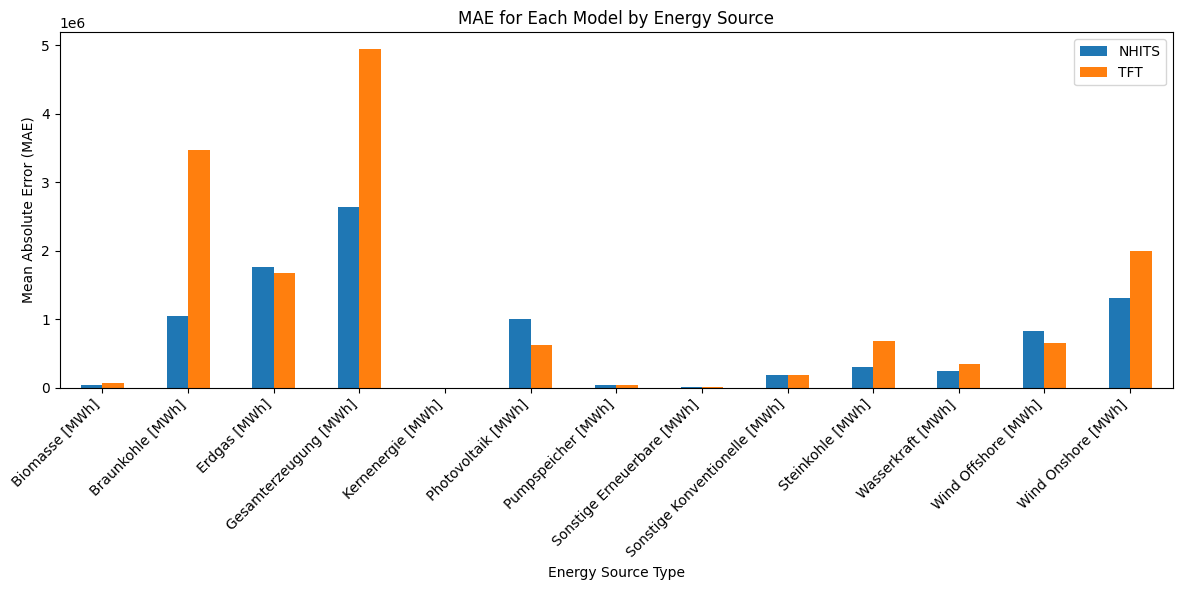

In [77]:
evaluation_to_plot = evaluation.drop(columns="metric").set_index("unique_id")

evaluation_to_plot.plot(kind="bar", figsize=(12, 6))
plt.ylabel("Mean Absolute Error (MAE)")
plt.xlabel("Energy Source Type")
plt.title("MAE for Each Model by Energy Source")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

NN Cross-Validation

In [78]:
models = [
    NHITS(h=3, input_size=12, n_pool_kernel_size=[4,2,1], n_freq_downsample=[12,4,1], scaler_type='robust', max_steps=1000, enable_progress_bar=False),
    TFT(h=3, input_size=12, hidden_size=128, scaler_type='robust', learning_rate=5e-4, max_steps=500, enable_progress_bar=False)
]

nf = NeuralForecast(models=models, freq='MS', local_scaler_type="standard")

cv_nf = nf.cross_validation(trainErzeugung, n_windows=4, step_size=3)
cv_nf.head()

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ blocks       │ ModuleList    │  2.4 M │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 2.4 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.4 M                                                                                                
Total estimated model params size (MB): 9                                                                          
Modules in train mode: 34                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1000` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


┏━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                    ┃ Type                     ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss                    │ MAE                      │      0 │ train │     0 │
│ 1 │ padder_train            │ ConstantPad1d            │      0 │ train │     0 │
│ 2 │ scaler                  │ TemporalNorm             │      0 │ train │     0 │
│ 3 │ embedding               │ TFTEmbedding             │    512 │ train │     0 │
│ 4 │ temporal_encoder        │ TemporalCovariateEncoder │  613 K │ train │     0 │
│ 5 │ temporal_fusion_decoder │ TemporalFusionDecoder    │  256 K │ train │     0 │
│ 6 │ output_adapter          │ Linear                   │    129 │ train │     0 │
└───┴─────────────────────────┴──────────────────────────┴────────┴───────┴───────┘

Trainable params: 870 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 870 K                                                                                                
Total estimated model params size (MB): 3                                                                          
Modules in train mode: 88                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=500` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


,unique_id,ds,cutoff,NHITS,TFT,y
0,Biomasse [MWh],2024-09-01,2024-08-01,2816495.75,2842871.75,2747048.00
1,Biomasse [MWh],2024-10-01,2024-08-01,2936890.25,2921440.75,3041499.25
2,Biomasse [MWh],2024-11-01,2024-08-01,2936986.25,2982508.25,3102041.50
3,Biomasse [MWh],2024-12-01,2024-11-01,3157619.00,3124190.50,3219102.00
4,Biomasse [MWh],2025-01-01,2024-11-01,3196849.75,3091408.75,3215965.00


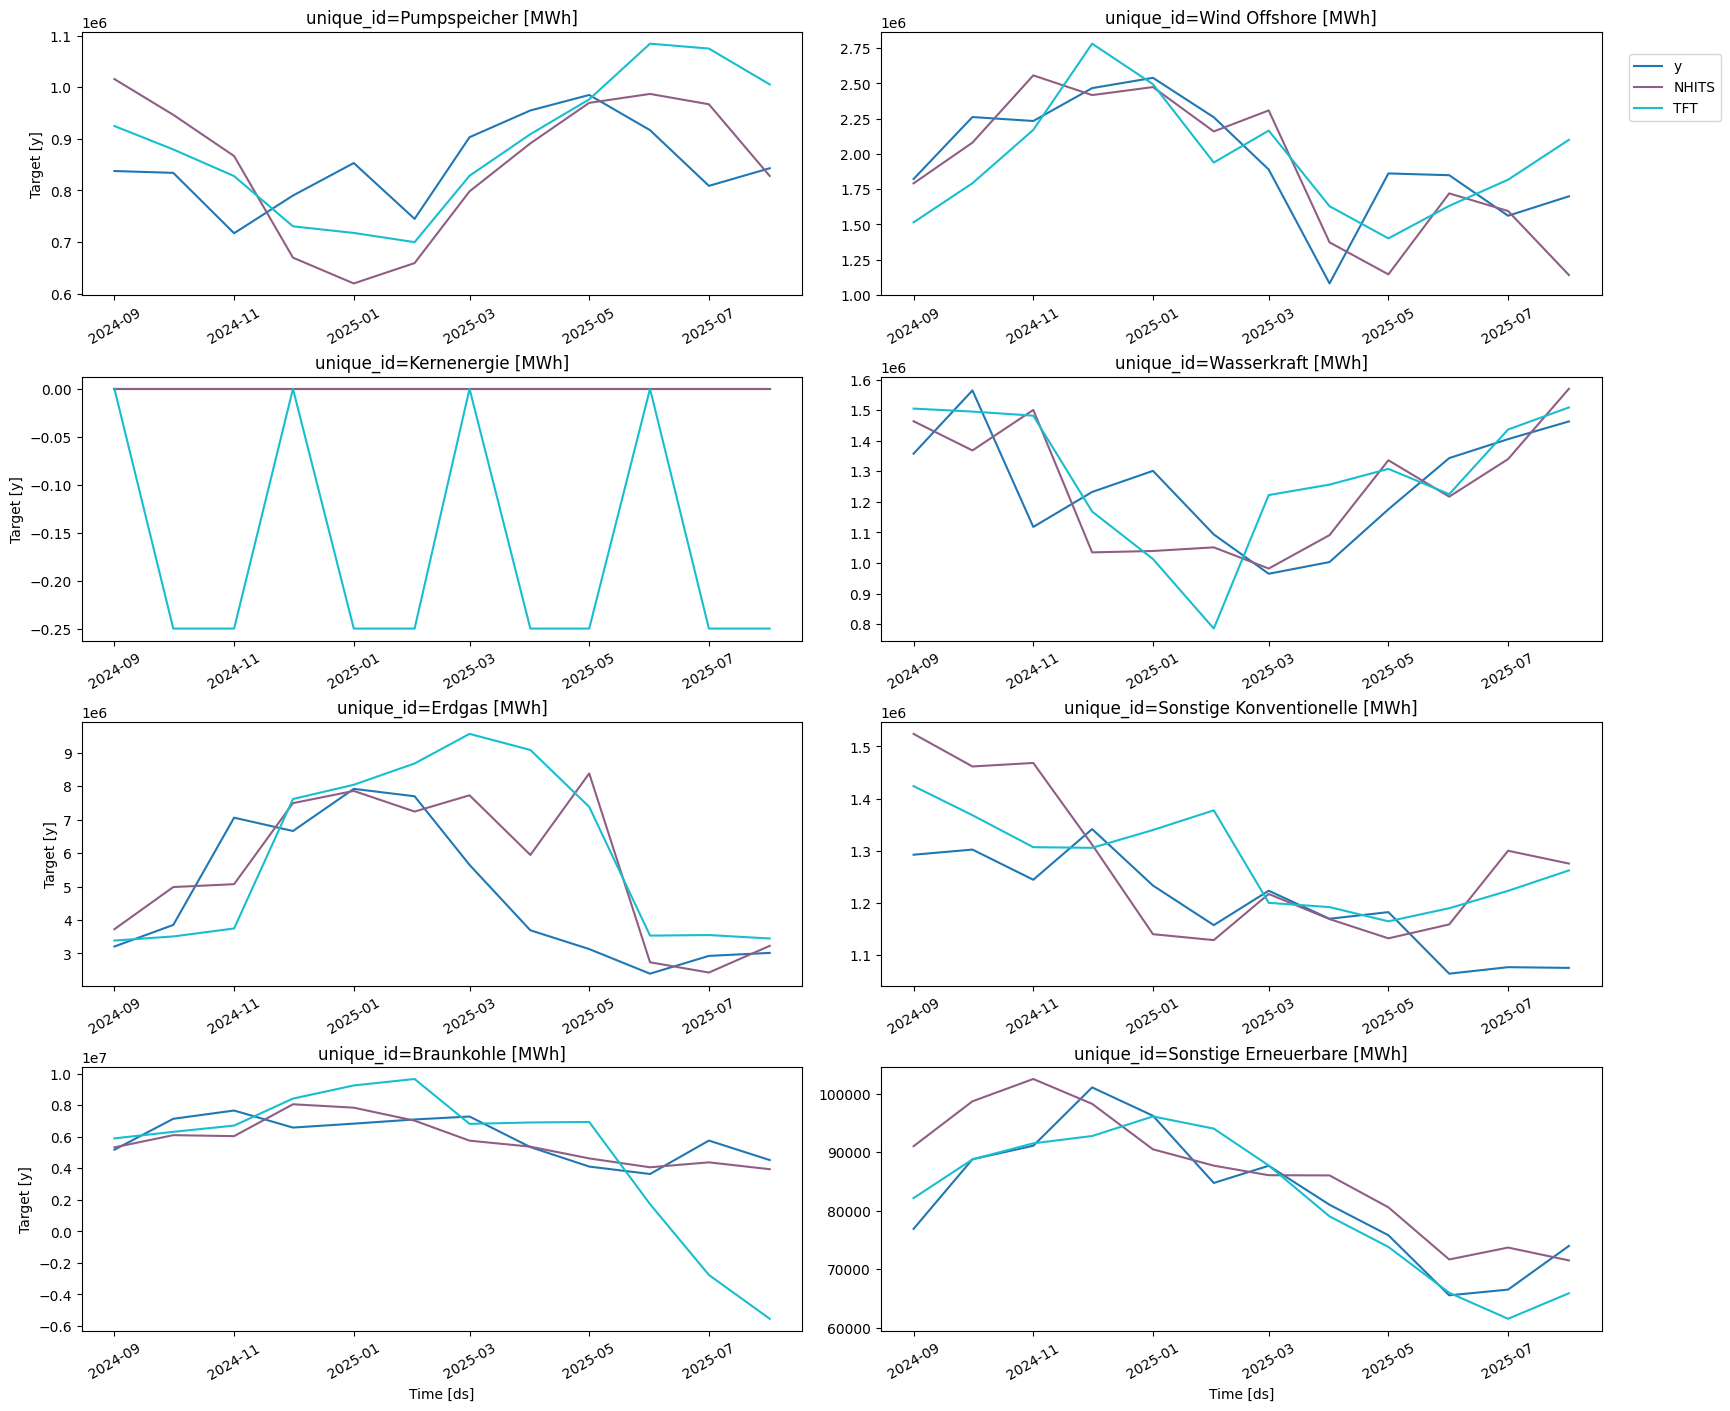

In [79]:
plot_series(forecasts_df=cv_nf.drop(columns='cutoff'))

<Axes: >

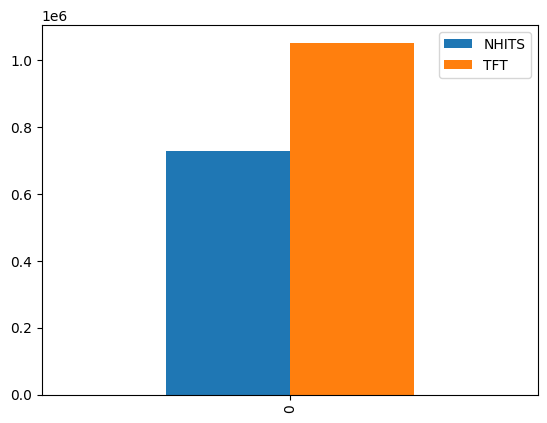

In [80]:
nf_cv_eval = evaluate(cv_nf.drop(columns="cutoff"), metrics=[mae])

nf_cv_eval = nf_cv_eval.drop(columns=["unique_id"]).groupby("metric").mean().reset_index()
nf_cv_eval.plot(kind="bar")

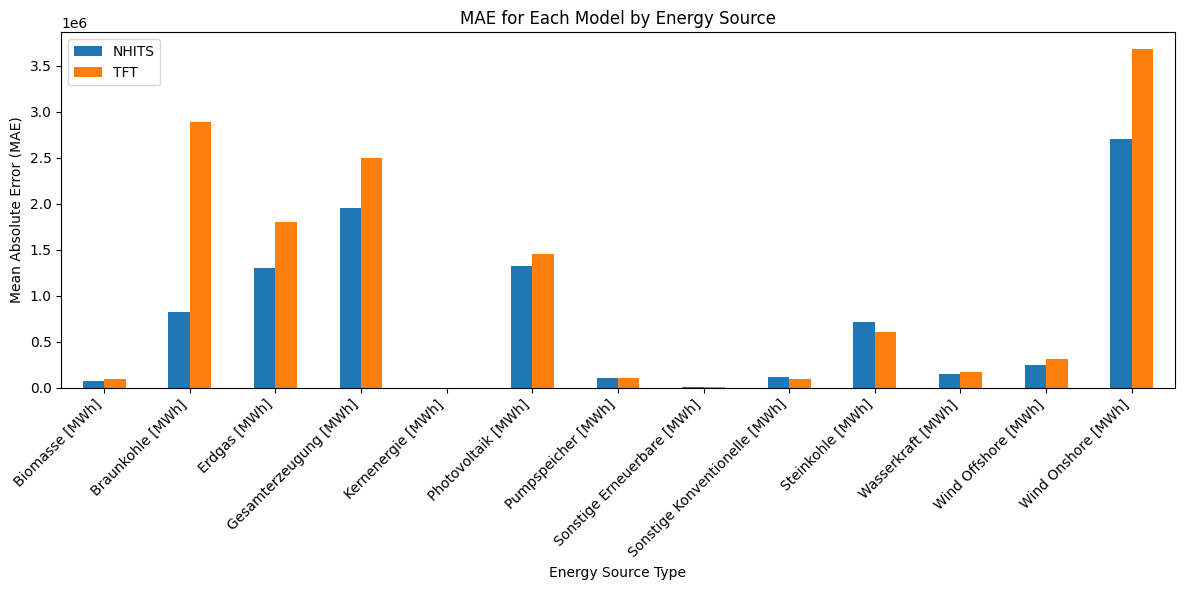

In [81]:
nf_cv_eval = evaluate(cv_nf.drop(columns="cutoff"), metrics=[mae])
nf_to_plot = nf_cv_eval.drop(columns="metric").set_index("unique_id")

nf_to_plot.plot(kind="bar", figsize=(12, 6))
plt.ylabel("Mean Absolute Error (MAE)")
plt.xlabel("Energy Source Type")
plt.title("MAE for Each Model by Energy Source")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

###Combined Plots

MAE

In [82]:
nf_cv_eval_tc = nf_cv_eval.drop(columns="metric")
mlf_cv_eval_tc = mlf_cv_eval.drop(columns="metric")
cv_eval_tc = evaluate(cv.drop(columns="cutoff"), metrics=[mae]).drop(columns="metric")

In [83]:
combined_cv = pd.merge(cv_eval_tc, mlf_cv_eval_tc)
combined_cv = pd.merge(combined_cv, nf_cv_eval_tc)
combined_cv = combined_cv.set_index("unique_id")
combined_cv

,ARIMA,SARIMA,SeasonalNaive,LinearRegression,XGBRegressor,LGBMRegressor,NHITS,TFT
unique_id,,,,,,,,
Biomasse [MWh],1.220515e+05,7.978566e+04,5.903879e+04,7.473400e+04,9.631858e+04,1.113551e+05,6.822714e+04,9.285269e+04
Braunkohle [MWh],1.181724e+06,1.251291e+06,7.399120e+05,8.102916e+05,1.047409e+06,8.319258e+05,8.190235e+05,2.887509e+06
Erdgas [MWh],1.387938e+06,1.309758e+06,8.535542e+05,1.073161e+06,7.562504e+05,6.770245e+05,1.303117e+06,1.805000e+06
Gesamterzeugung [MWh],2.172706e+06,1.563005e+06,1.781643e+06,1.633853e+06,1.708066e+06,1.922992e+06,1.952075e+06,2.496647e+06
Kernenergie [MWh],2.507439e+05,4.076905e+04,0.000000e+00,4.321236e+05,2.755069e+04,3.768864e+04,0.000000e+00,1.666667e-01
Photovoltaik [MWh],1.709738e+06,7.980416e+05,8.932796e+05,1.560785e+06,1.744954e+06,1.760802e+06,1.321218e+06,1.450563e+06
Pumpspeicher [MWh],1.248701e+05,1.248701e+05,8.423975e+04,9.339296e+04,8.823935e+04,1.023824e+05,1.088210e+05,1.006600e+05
Sonstige Erneuerbare [MWh],6.647012e+03,5.238898e+03,1.254560e+04,9.426221e+03,1.314639e+04,8.772197e+03,6.172471e+03,3.409453e+03
Sonstige Konventionelle [MWh],7.433690e+04,7.732087e+04,1.699632e+05,7.714511e+04,8.662903e+04,8.173142e+04,1.116582e+05,9.523384e+04


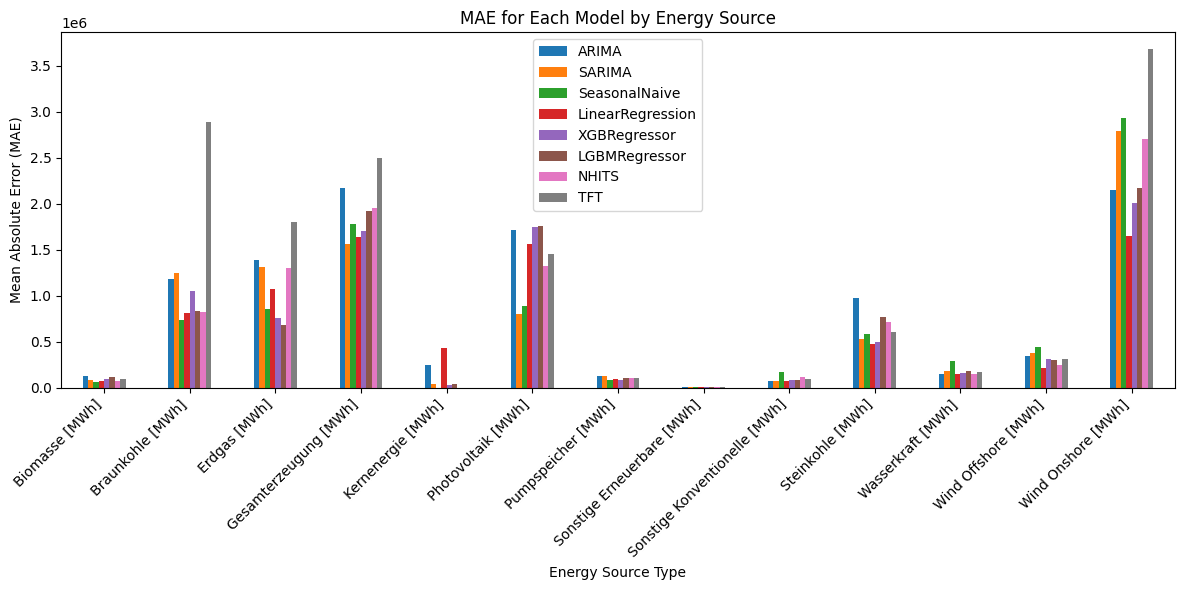

In [84]:
combined_cv.plot(kind="bar", figsize=(12, 6))
plt.ylabel("Mean Absolute Error (MAE)")
plt.xlabel("Energy Source Type")
plt.title("MAE for Each Model by Energy Source")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Combined Predictions

In [85]:
combinedPreds = pd.merge(testErzeugung, predStatErz, "left", ["ds", "unique_id"])
combinedPreds = pd.merge(combinedPreds, predMlErz, "left", ["ds", "unique_id"])
combinedPreds = pd.merge(combinedPreds, predNNErz, "left", ["ds", "unique_id"])
combinedPreds.head()

,ds,unique_id,y,ARIMA,SARIMA,SeasonalNaive,LinearRegression,XGBRegressor,LGBMRegressor,NHITS,TFT
0,2025-09-01,Gesamterzeugung [MWh],34504645.87,3.197515e+07,3.217717e+07,33809086.75,3.462713e+07,3.187389e+07,3.070090e+07,32178052.0,32741098.00
1,2025-10-01,Gesamterzeugung [MWh],39873287.81,3.197515e+07,3.424926e+07,34759714.00,3.658503e+07,3.298893e+07,3.365014e+07,35440156.0,32710056.00
2,2025-11-01,Gesamterzeugung [MWh],38483562.69,3.197515e+07,3.694509e+07,38701564.75,3.809285e+07,3.547083e+07,3.616032e+07,39625360.0,32594134.00
3,2025-09-01,Biomasse [MWh],2794210.42,2.867677e+06,2.735789e+06,2747048.00,2.959830e+06,2.904058e+06,2.835910e+06,2816280.5,2956479.25
4,2025-10-01,Biomasse [MWh],3012369.21,2.860004e+06,2.978532e+06,3041499.25,3.011095e+06,2.988186e+06,2.980338e+06,3078998.5,3036784.75


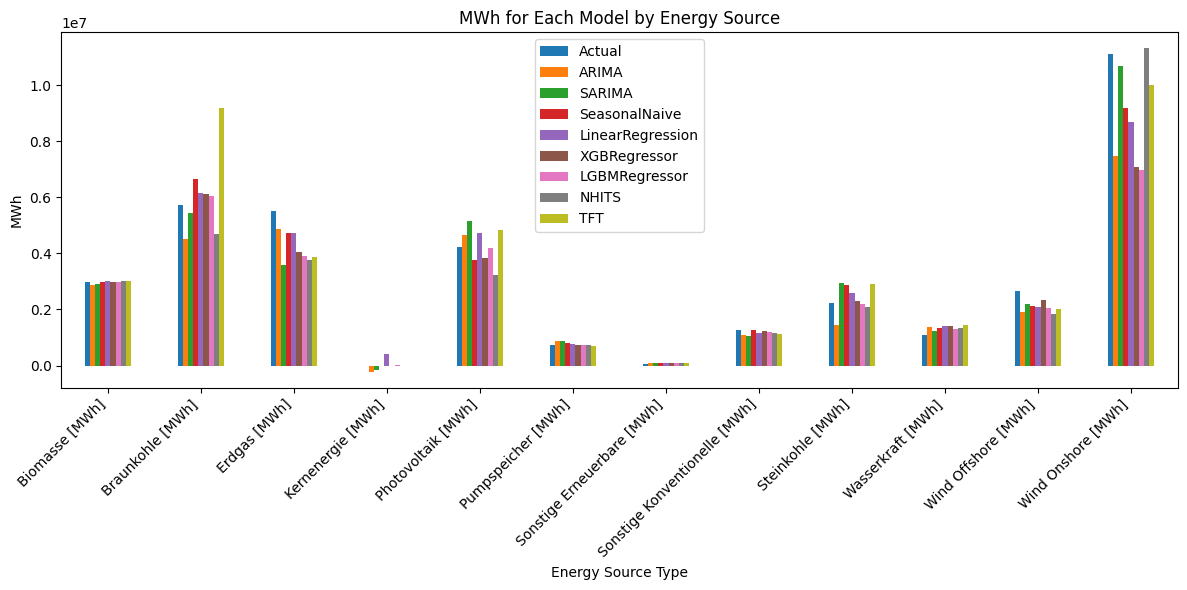

In [86]:
combPredsExGesamt = combinedPreds.loc[combinedPreds["unique_id"] != "Gesamterzeugung [MWh]"]
combPredsExGesamt = combPredsExGesamt.drop(columns="ds")
combPredsExGesamt = combPredsExGesamt.set_index("unique_id")
combPredsExGesamt = combPredsExGesamt.rename(columns={"y": "Actual"})

combPredsExGesamt.groupby(combPredsExGesamt.index).mean().plot(kind="bar", figsize=(12, 6))
plt.ylabel("MWh")
plt.xlabel("Energy Source Type")
plt.title("MWh for Each Model by Energy Source")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

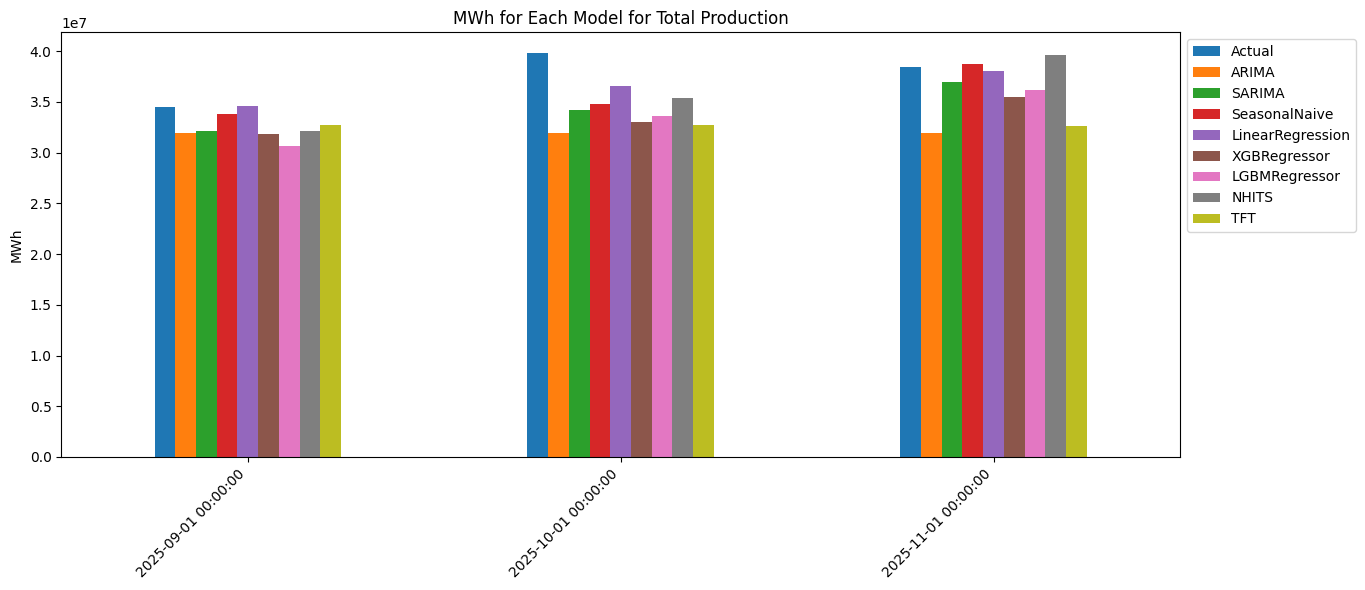

In [87]:
combPredsGesamt = combinedPreds.loc[combinedPreds["unique_id"] == "Gesamterzeugung [MWh]"]
combPredsGesamt = combPredsGesamt.drop(columns="unique_id")
combPredsGesamt = combPredsGesamt.set_index("ds")
combPredsGesamt = combPredsGesamt.rename(columns={"y": "Actual"})

combPredsGesamt.groupby(combPredsGesamt.index).mean().plot(kind="bar", figsize=(12, 6))
plt.ylabel("MWh")
plt.xlabel("")
plt.title("MWh for Each Model for Total Production")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.show()

###Forecast Plot with Best ML Model

In [88]:
statmodels = ["ARIMA", "SARIMA", "SeasonalNaive"]
bestForecastModel = combined_cv.loc["Gesamterzeugung [MWh]"].drop(labels=statmodels, axis=0).idxmin()
bestForecastModel

'LinearRegression'

In [89]:
forecast = combinedPreds.loc[combinedPreds["unique_id"] == "Gesamterzeugung [MWh]", ["ds", bestForecastModel]]
forecast = forecast.set_index("ds")
forecast

,LinearRegression
ds,
2025-09-01,3.462713e+07
2025-10-01,3.658503e+07
2025-11-01,3.809285e+07


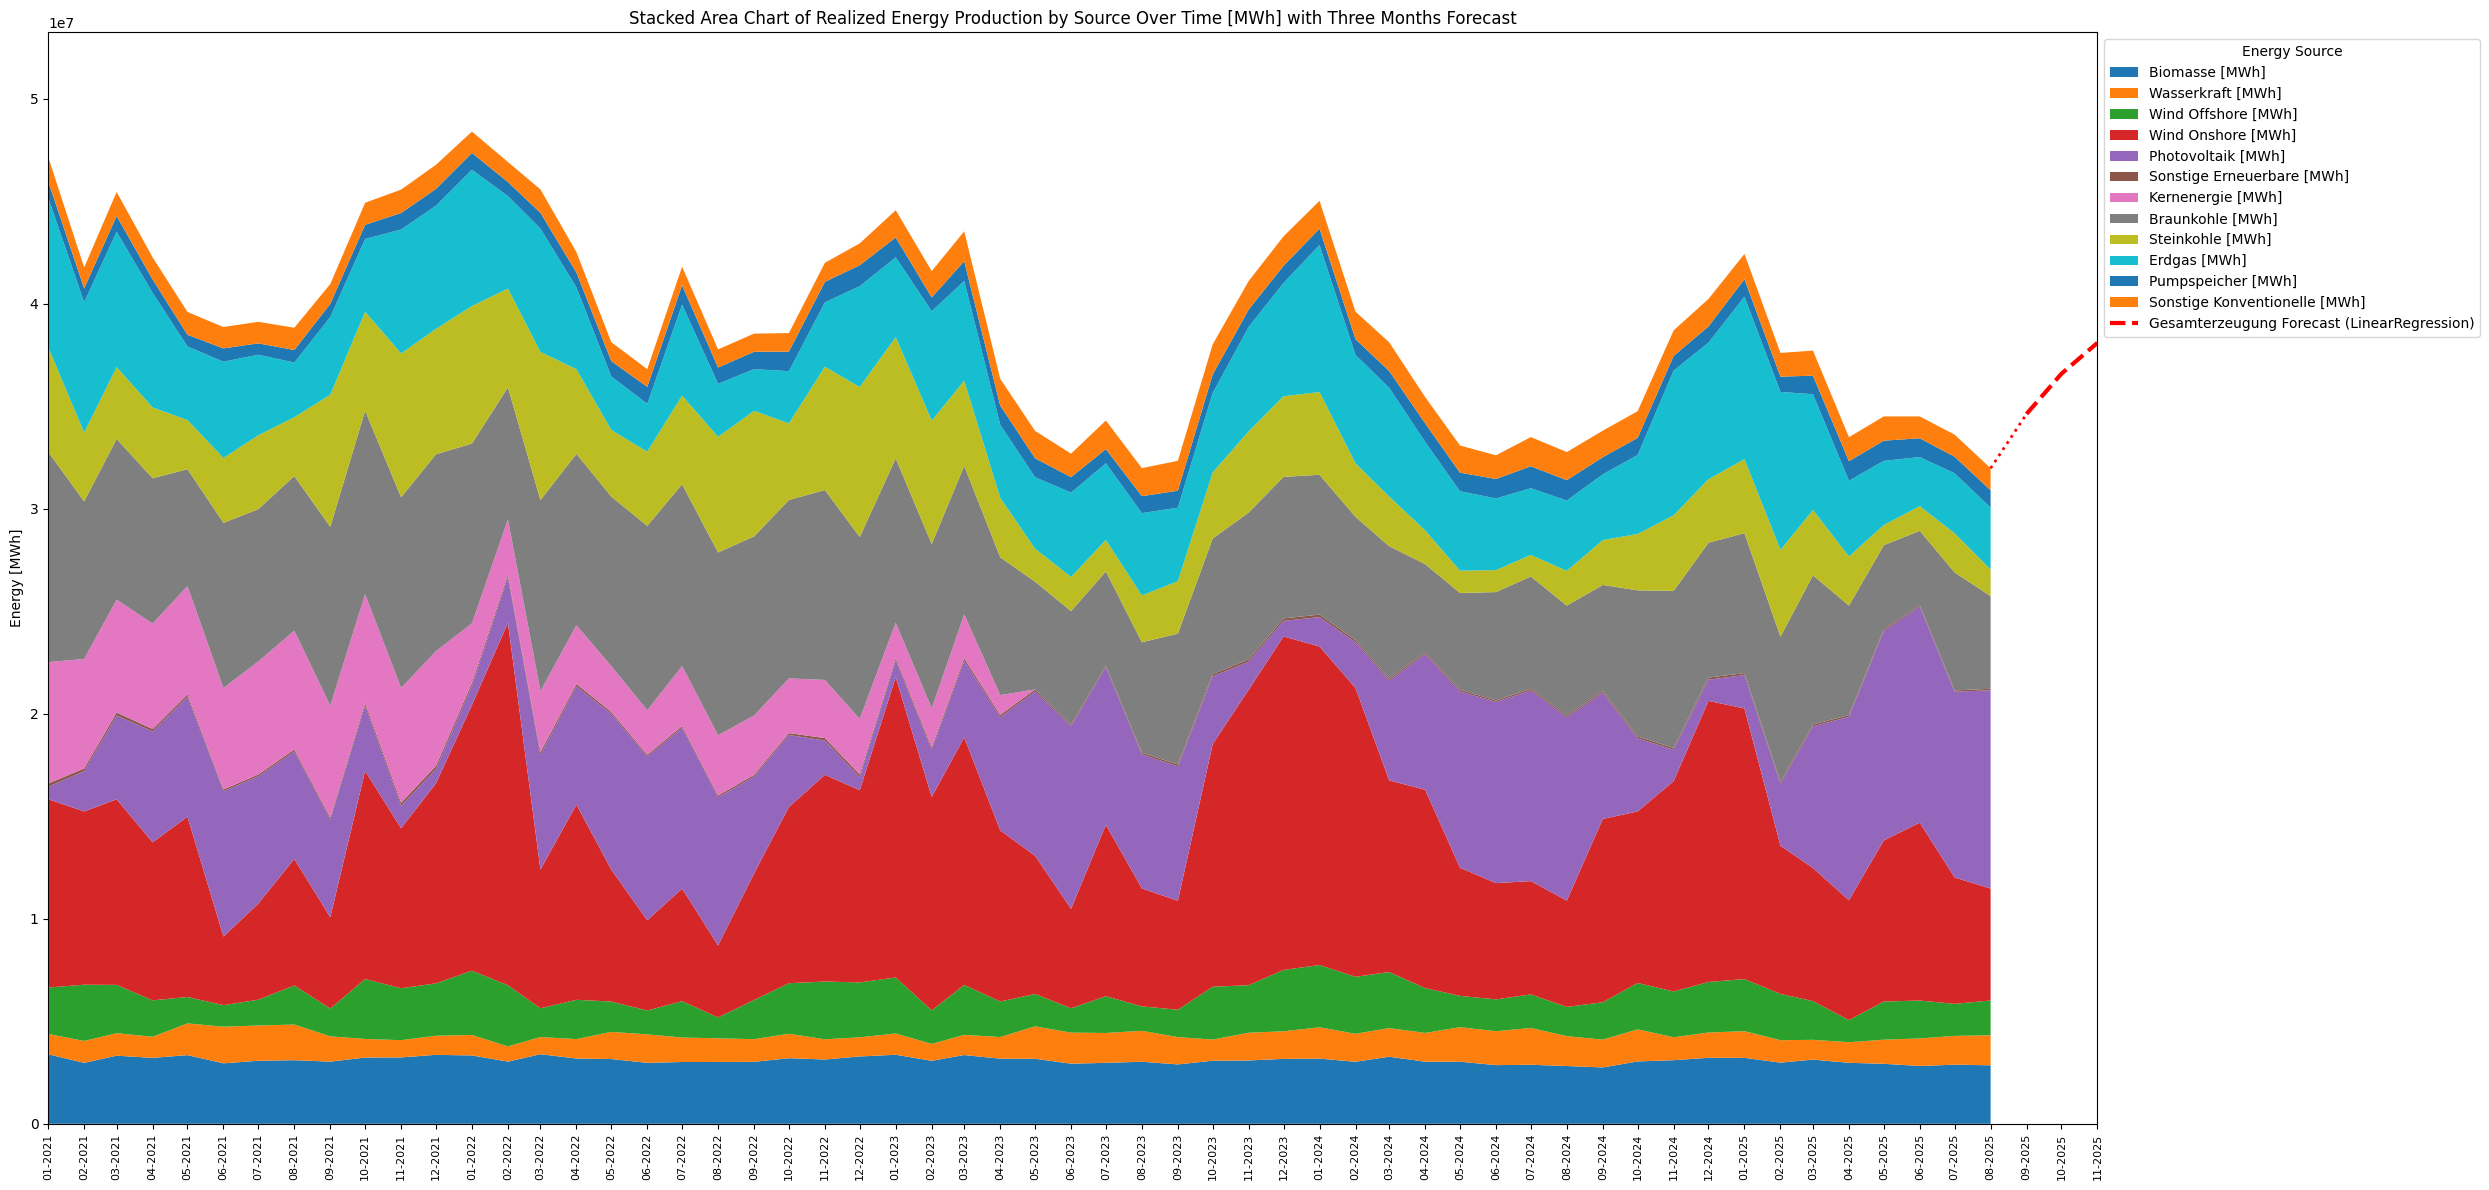

In [90]:
erzeugungPlotDf = erzeugung.iloc[:-3].set_index("Datum von").drop(columns=["Datum bis", "Gesamterzeugung [MWh]"])

productionDates = erzeugungPlotDf.index
forecastDates = forecast.index
allDates = productionDates.append(forecastDates)
allLabels = allDates.strftime("%m-%Y")

fig, ax = plt.subplots(figsize=(25, 12))

ax.stackplot(erzeugungPlotDf.index, erzeugungPlotDf.values.T, labels=erzeugungPlotDf.columns)
ax.plot(forecast.index, forecast[bestForecastModel], color='red', linestyle="--", linewidth=3, label=f'Gesamterzeugung Forecast ({bestForecastModel})')

last_historical_total = erzeugungPlotDf.sum(axis=1).iloc[-1]
first_forecast_value = forecast[bestForecastModel].iloc[0]

bridge_x = [productionDates.max(), forecastDates.min()]
bridge_y = [last_historical_total, first_forecast_value]
ax.plot(bridge_x, bridge_y, color='red', linestyle=':', linewidth=2)

max_historical_sum = erzeugungPlotDf.sum(axis=1).max()
max_forecast_value = forecast[f'{bestForecastModel}'].max()
max_y_value = max(max_historical_sum, max_forecast_value)
ax.set_ylim(bottom=0, top=max_y_value * 1.1)

ax.set_xlim(allDates.min(), allDates.max())
ax.set_xticks(allDates)
ax.set_xticklabels(allLabels, rotation=90, ha='center', fontsize=8)

ax.set_title('Stacked Area Chart of Realized Energy Production by Source Over Time [MWh] with Three Months Forecast')
ax.set_ylabel('Energy [MWh]')
ax.set_xlabel('')
ax.legend(title='Energy Source', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()